# 作業 2：迴歸模型與台北房價預測

本作業使用 `Taipei_house.csv` 練習迴歸模型。

請將 `Taipei_house.csv` 與本 Notebook 放在同一個資料夾中，再依序執行每個程式區塊。

---

## 本作業學習重點

本作業是根據課堂教材 `2.ipynb` 簡化而來，保留每一類重要知識點，但同類型方法只選一個代表做法練習。

你會練習：

1. 讀取資料與觀察資料
2. 簡單線性迴歸
3. 標準化
4. 儲存與載入模型
5. 多元線性迴歸
6. 訓練集與測試集切分
7. 迴歸模型評估指標
8. 殘差分析
9. 正規化迴歸
10. 多項式迴歸
11. 隨機森林迴歸
12. 模型結果視覺化比較

---

## 注意事項

本作業刻意採用較簡單的寫法：

- 不使用 `Pipeline`
- 不使用 list comprehension
- 程式碼以初學者容易閱讀為主
- 需要檢查結果的地方會加入視覺化

## 0. 匯入套件與設定圖表

這一段負責匯入常用套件，並設定中文字型，讓圖表可以顯示中文。

In [1]:
# 忽略警告訊息，避免畫面太雜亂
import warnings
warnings.filterwarnings("ignore")

# 基本資料處理套件
import numpy as np
import pandas as pd

# 視覺化套件
import matplotlib.pyplot as plt

# 機器學習常用工具
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 儲存與載入模型
import joblib

# 設定圖表大小
plt.rcParams["figure.figsize"] = (8, 5)

# 設定中文字型
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 讓負號可以正常顯示
plt.rcParams["axes.unicode_minus"] = False

## 1. 讀取資料與欄位說明

本資料集是台北房價資料，目標變數是 `總價`。

常見欄位說明如下：

| 欄位名稱 | 說明 |
|---|---|
| `行政區` | 房屋所在行政區 |
| `土地面積` | 土地面積 |
| `建物總面積` | 建物總面積 |
| `屋齡` | 房屋年齡 |
| `樓層` | 交易物件所在樓層 |
| `總樓層` | 建物總樓層 |
| `用途` | 用途類別，這裡已經是數值編碼 |
| `房數` | 房間數 |
| `廳數` | 客廳數 |
| `衛數` | 衛浴數 |
| `電梯` | 是否有電梯，通常 `1` 表示有，`0` 表示沒有 |
| `車位類別` | 車位類型 |
| `交易日期` | 房屋交易日期 |
| `經度` | 地理位置經度 |
| `緯度` | 地理位置緯度 |
| `總價` | 房屋總價，也是本作業要預測的目標 |

In [2]:
# 讀取資料
df = pd.read_csv("Taipei_house.csv")

# 顯示前 5 筆資料
df.head()

,行政區,土地面積,建物總面積,屋齡,樓層,總樓層,用途,房數,廳數,衛數,電梯,車位類別,交易日期,經度,緯度,總價
0,文山區,33.81,109.42,38.996009,3,5,0,3,2,2,0,無,2019/10/6,121.552517,25.004507,1000
1,文山區,32.19,163.53,23.781460,3,11,0,3,2,2,1,坡道平面,2019/4/28,121.559133,24.983199,2100
2,文山區,60.25,204.79,0.744711,1,10,0,3,2,3,1,無,2019/10/23,121.576052,24.988665,6720
3,文山區,16.99,80.31,0.506513,5,10,0,3,2,2,1,坡道平面,2019/7/28,121.576052,24.988665,1110
4,文山區,25.98,86.73,36.099304,4,5,0,3,2,2,0,無,2019/9/28,121.563486,24.995213,800


In [3]:
# 查看資料筆數與欄位數
df.shape

(12429, 16)

In [4]:
# 查看欄位型態與缺失值狀況
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12429 entries, 0 to 12428
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   行政區     12429 non-null  str    
 1   土地面積    12429 non-null  float64
 2   建物總面積   12429 non-null  float64
 3   屋齡      12429 non-null  float64
 4   樓層      12429 non-null  int64  
 5   總樓層     12429 non-null  int64  
 6   用途      12429 non-null  int64  
 7   房數      12429 non-null  int64  
 8   廳數      12429 non-null  int64  
 9   衛數      12429 non-null  int64  
 10  電梯      12429 non-null  int64  
 11  車位類別    12429 non-null  str    
 12  交易日期    12429 non-null  str    
 13  經度      12429 non-null  float64
 14  緯度      12429 non-null  float64
 15  總價      12429 non-null  int64  
dtypes: float64(5), int64(8), str(3)
memory usage: 1.5 MB


In [5]:
# 查看數值欄位的基本統計資訊
df.describe()

,土地面積,建物總面積,屋齡,樓層,總樓層,用途,房數,廳數,衛數,電梯,經度,緯度,總價
count,12429.000000,12429.000000,12429.000000,12429.000000,12429.000000,12429.000000,12429.00000,12429.00000,12429.000000,12429.000000,12429.000000,12429.000000,12429.000000
mean,25.912769,126.443538,22.520371,5.926623,10.470995,0.106927,2.61976,1.70770,1.661035,0.808754,121.557058,25.023766,2483.747928
std,20.941107,81.783144,14.358367,3.803564,5.269337,0.309033,1.10493,0.55114,0.728569,0.393298,0.014377,0.024504,2610.136585
min,0.000000,0.070000,-7.044635,1.000000,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,121.520401,24.970723,1.000000
25%,12.300000,76.530000,9.610054,3.000000,6.000000,0.000000,2.00000,1.00000,1.000000,1.000000,121.546687,24.999671,1235.000000
50%,22.860000,112.360000,24.241429,5.000000,10.000000,0.000000,3.00000,2.00000,2.000000,1.000000,121.557345,25.027715,1950.000000
75%,33.050000,156.440000,34.527745,8.000000,14.000000,0.000000,3.00000,2.00000,2.000000,1.000000,121.568000,25.044595,2888.000000
max,387.810000,1157.420000,53.928554,30.000000,38.000000,1.000000,13.00000,8.00000,13.000000,1.000000,121.614872,25.073358,60741.000000


### 作業問題 1

請回答：

1. 這份資料有幾筆資料？
2. 目標變數是哪一個欄位？
3. 你認為哪一個特徵最可能影響房價？為什麼？

## 2. 資料視覺化：觀察特徵與房價的關係

在建立模型之前，先用散佈圖觀察 `建物總面積` 與 `總價` 的關係。

如果兩者大致呈現「面積越大，總價越高」，表示線性迴歸可能可以學到一定的關係。

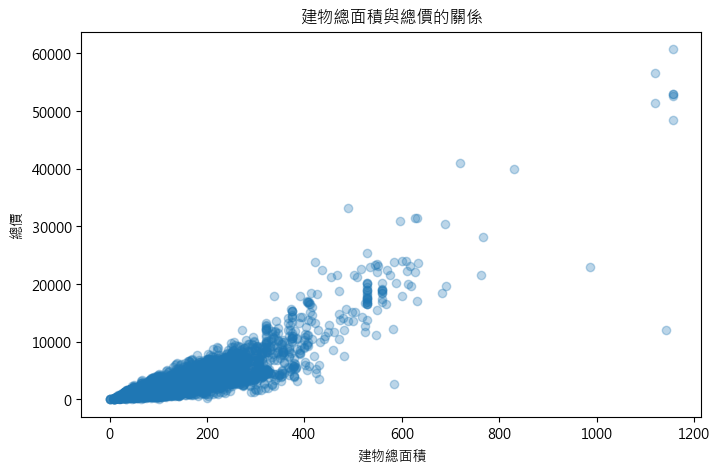

In [6]:
plt.scatter(df["建物總面積"], df["總價"], alpha=0.3)

plt.xlabel("建物總面積")
plt.ylabel("總價")
plt.title("建物總面積與總價的關係")

plt.show()

### 作業問題 2

請觀察上圖並回答：

1. `建物總面積` 與 `總價` 看起來是否有正相關？
2. 圖中是否有少數價格特別高的資料點？
3. 這些極端值可能會對線性迴歸造成什麼影響？

## 3. 簡單線性迴歸

簡單線性迴歸只使用一個特徵預測目標變數。

本節使用 `建物總面積` 預測 `總價`。

模型形式為：

$$
y = w_0 + w_1 x
$$

其中：

- $x$：輸入特徵，這裡是 `建物總面積`
- $y$：預測目標，這裡是 `總價`
- $w_0$：截距
- $w_1$：係數，也可以理解成斜率

In [7]:
# ============================================================
# 簡單線性迴歸：使用「建物總面積」預測「總價」
# ============================================================

# X 必須是二維資料，所以使用兩層中括號
X_simple = df[["建物總面積"]]

# y 是一維資料
y = df["總價"]

# 建立線性迴歸模型
simple_model = LinearRegression()

# 訓練模型
simple_model.fit(X_simple, y)

# 取得模型預測值
simple_pred = simple_model.predict(X_simple)

# 顯示截距與係數
print("截距：", simple_model.intercept_)
print("係數：", simple_model.coef_[0])

截距： -923.370247494991
係數： 26.945767385046107


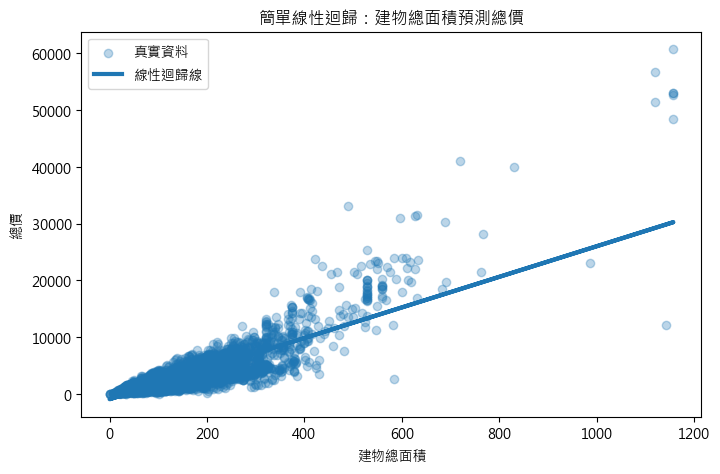

In [8]:
# ============================================================
# 視覺化：原始資料點與線性迴歸線
# ============================================================

plt.scatter(df["建物總面積"], df["總價"], alpha=0.3, label="真實資料")
plt.plot(df["建物總面積"], simple_pred, linewidth=3, label="線性迴歸線")

plt.xlabel("建物總面積")
plt.ylabel("總價")
plt.title("簡單線性迴歸：建物總面積預測總價")
plt.legend()

plt.show()

### 作業問題 3

請回答：

1. 係數是正數還是負數？
2. 係數代表什麼意思？
3. 你覺得只用 `建物總面積` 預測房價是否足夠？為什麼？

## 4. 儲存與載入模型

模型訓練完成後，可以使用 `joblib` 儲存。

這樣之後就不需要重新訓練，可以直接載入模型做預測。

In [9]:
# 儲存模型
joblib.dump(simple_model, "simple_linear_regression_model.pkl")

print("模型已儲存")

模型已儲存


In [10]:
# 載入模型
loaded_simple_model = joblib.load("simple_linear_regression_model.pkl")

# 建立一筆新資料
new_house = pd.DataFrame({
    "建物總面積": [120]
})

# 使用載入後的模型進行預測
new_prediction = loaded_simple_model.predict(new_house)

print("建物總面積 120 的預測總價：", new_prediction[0])

建物總面積 120 的預測總價： 2310.121838710542


### 作業問題 4

請把 `建物總面積` 改成 80、150、200，觀察預測總價如何變化。

## 5. 標準化

標準化會把特徵轉換成平均值接近 0、標準差接近 1 的尺度。

標準化常用在：

- 線性迴歸
- Ridge Regression
- Lasso Regression
- Elastic Net
- 支援向量機
- KNN

標準化公式如下：

$$
z = \frac{x - \mu}{\sigma}
$$

其中：

- $x$：原始值
- $\mu$：平均值
- $\sigma$：標準差
- $z$：標準化後的值

In [11]:
# 建立標準化器
scaler_simple = StandardScaler()

# 對「建物總面積」進行標準化
X_simple_scaled = scaler_simple.fit_transform(X_simple)

# 建立模型
simple_scaled_model = LinearRegression()

# 使用標準化後的資料訓練模型
simple_scaled_model.fit(X_simple_scaled, y)

# 產生預測結果
simple_scaled_pred = simple_scaled_model.predict(X_simple_scaled)

print("標準化後模型的截距：", simple_scaled_model.intercept_)
print("標準化後模型的係數：", simple_scaled_model.coef_[0])

標準化後模型的截距： 2483.74792823236
標準化後模型的係數： 2203.6209297988466


In [12]:
# ============================================================
# 使用標準化後的模型預測新資料
# ============================================================

# 新資料仍然要先做標準化，不能直接丟進模型
new_house = pd.DataFrame({
    "建物總面積": [120]
})

# 使用前面 fit 過的 scaler 轉換新資料
new_house_scaled = scaler_simple.transform(new_house)

# 預測
new_scaled_prediction = simple_scaled_model.predict(new_house_scaled)

print("建物總面積 120 的預測總價：", new_scaled_prediction[0])

建物總面積 120 的預測總價： 2310.121838710542


### 作業問題 5

請回答：

1. 為什麼新資料也要使用同一個 `scaler_simple` 做標準化？
2. 標準化會不會改變模型預測的目標單位？

## 6. 訓練集與測試集切分

為了檢查模型是否能預測「沒看過的新資料」，通常會把資料切成：

- 訓練集：用來訓練模型
- 測試集：用來評估模型表現

本作業使用 80% 作為訓練集，20% 作為測試集。

In [13]:
# 選擇多個數值特徵
feature_columns = [
    "土地面積",
    "建物總面積",
    "屋齡",
    "樓層",
    "總樓層",
    "用途",
    "房數",
    "廳數",
    "衛數",
    "電梯",
    "經度",
    "緯度"
]

X = df[feature_columns]
y = df["總價"]

# 切分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train 形狀：", X_train.shape)
print("X_test 形狀：", X_test.shape)
print("y_train 形狀：", y_train.shape)
print("y_test 形狀：", y_test.shape)

X_train 形狀： (9943, 12)
X_test 形狀： (2486, 12)
y_train 形狀： (9943,)
y_test 形狀： (2486,)


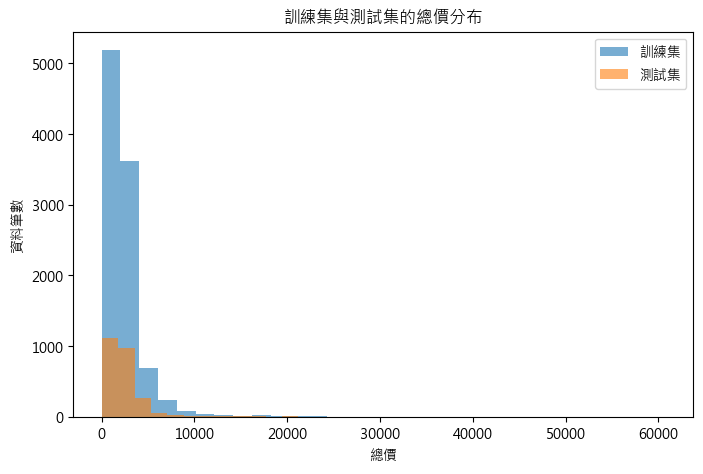

In [14]:
# 視覺化訓練集與測試集的目標變數分布

plt.hist(y_train, bins=30, alpha=0.6, label="訓練集")
plt.hist(y_test, bins=30, alpha=0.6, label="測試集")

plt.xlabel("總價")
plt.ylabel("資料筆數")
plt.title("訓練集與測試集的總價分布")
plt.legend()

plt.show()

### 作業問題 6

請回答：

1. 訓練集有幾筆資料？
2. 測試集有幾筆資料？
3. 為什麼不能只看訓練集表現？

## 7. 多元線性迴歸

多元線性迴歸會同時使用多個特徵預測目標變數。

模型形式為：

$$
y = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_p x_p
$$

其中每一個 $x$ 代表不同特徵，例如建物總面積、屋齡、房數等。

In [15]:
# 建立多元線性迴歸模型
multiple_model = LinearRegression()

# 使用訓練集訓練模型
multiple_model.fit(X_train, y_train)

# 使用測試集預測
multiple_pred = multiple_model.predict(X_test)

# 顯示截距
print("截距：", multiple_model.intercept_)

# 顯示各特徵係數
coef_df = pd.DataFrame({
    "特徵名稱": feature_columns,
    "係數": multiple_model.coef_
})

coef_df

截距： 1219362.016699516


,特徵名稱,係數
0,土地面積,-7.699449
1,建物總面積,30.344088
2,屋齡,0.311144
3,樓層,5.550095
4,總樓層,10.795765
5,用途,-81.177603
6,房數,-424.859522
7,廳數,-204.667857
8,衛數,296.822914
9,電梯,-276.280228


## 8. 迴歸模型評估指標

迴歸模型常見評估指標包含：

| 指標 | 中文名稱 | 意義 |
|---|---|---|
| MSE | 平均平方誤差 | 誤差平方後取平均，會放大大誤差 |
| RMSE | 均方根誤差 | MSE 開根號，單位與目標變數相同 |
| MAE | 平均絕對誤差 | 預測誤差的絕對值平均 |
| R² | 決定係數 | 模型能解釋目標變異的比例 |

為了簡化，本作業主要使用 **RMSE**。

RMSE 越小，表示模型預測誤差越小。

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

In [16]:
# 計算 RMSE
multiple_mse = mean_squared_error(y_test, multiple_pred)
multiple_rmse = np.sqrt(multiple_mse)

print("多元線性迴歸 RMSE：", multiple_rmse)

多元線性迴歸 RMSE： 1252.919086099146


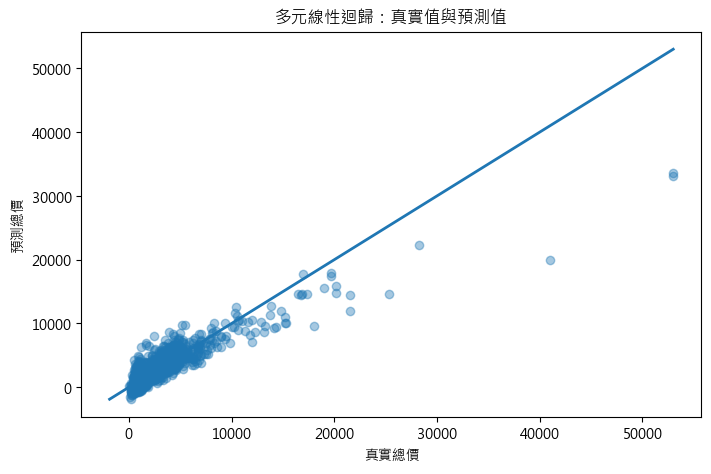

In [17]:
# 視覺化：真實值 vs 預測值

plt.scatter(y_test, multiple_pred, alpha=0.4)

plt.xlabel("真實總價")
plt.ylabel("預測總價")
plt.title("多元線性迴歸：真實值與預測值")

# 畫出理想情況的對角線
min_value = min(y_test.min(), multiple_pred.min())
max_value = max(y_test.max(), multiple_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linewidth=2)

plt.show()

### 關於 R² 與 Adjusted R²

教材中有提到 R² 與 Adjusted R²。

這裡只做概念提醒：

- R² 越高，通常代表模型解釋能力越好。
- 但是只要一直增加特徵，R² 可能會變高，即使那些特徵沒有真正幫助。
- Adjusted R² 會考慮特徵數量，避免模型只是靠增加特徵讓 R² 看起來變好。

本作業不要求手動計算 Adjusted R²，只需要理解它的用途。

### 作業問題 7

請回答：

1. 本模型的 RMSE 大約是多少？
2. RMSE 的單位是什麼？
3. 如果 RMSE 下降，代表模型變好還是變差？

## 9. 殘差分析

殘差是：

$$
殘差 = 真實值 - 預測值
$$

教材中提到多種殘差檢查方法，例如：

- 常態性檢查
- QQ 圖
- Durbin-Watson 檢定
- 變異數同質性檢查
- LOWESS 殘差趨勢線

為了簡化，本作業只使用 **殘差圖**。

殘差圖可以幫助我們觀察：

1. 模型是否有系統性偏誤
2. 殘差是否集中在 0 附近
3. 預測值越大時，誤差是否也越大

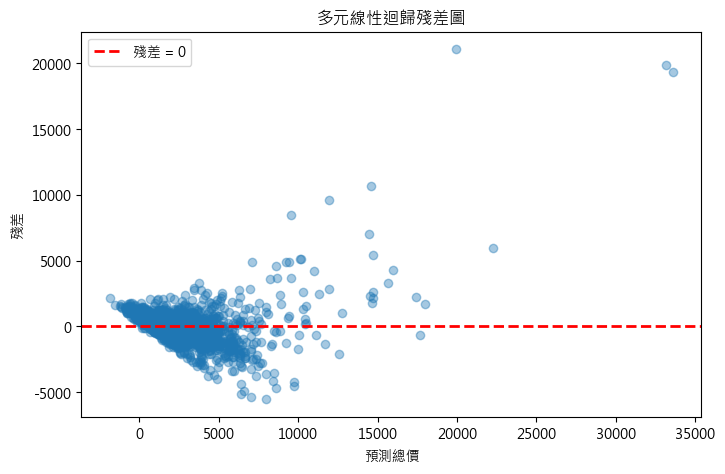

In [18]:
# 計算殘差
# 殘差 = 真實值 - 預測值
residuals = y_test - multiple_pred

# 畫殘差圖
plt.figure(figsize=(8, 5))

# x 軸是模型預測的房價，y 軸是殘差
plt.scatter(multiple_pred, residuals, alpha=0.4)

# 畫出殘差 = 0 的水平參考線
# 這條線可以幫助我們判斷模型是否有系統性高估或低估
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="殘差 = 0"
)

plt.xlabel("預測總價")
plt.ylabel("殘差")
plt.title("多元線性迴歸殘差圖")
plt.legend()

plt.show()

### 作業問題 8

請觀察殘差圖並回答：

1. 殘差是否大多分布在 0 附近？
2. 是否有少數殘差非常大的資料點？
3. 預測總價越高時，殘差是否變得更分散？

## 10. 正規化迴歸：Ridge Regression

正規化迴歸用來限制模型係數，降低模型過度配適的風險。

教材中提到三種方法：

| 方法 | 說明 |
|---|---|
| Ridge Regression | 讓係數不要過大 |
| Lasso Regression | 可以把部分係數壓到 0，具有特徵選擇效果 |
| Elastic Net | 結合 Ridge 與 Lasso |

為了簡化，本作業只實作 **Ridge Regression**。

Ridge 通常會搭配標準化，因為不同特徵的尺度可能差異很大。

In [19]:
# ============================================================
# Ridge Regression 需要先標準化特徵
# ============================================================

# 建立標準化器
scaler = StandardScaler()

# 對訓練集 fit，再 transform
X_train_scaled = scaler.fit_transform(X_train)

# 對測試集只能 transform，不能重新 fit
X_test_scaled = scaler.transform(X_test)

# 建立 Ridge 模型
ridge_model = Ridge(alpha=1.0)

# 訓練 Ridge 模型
ridge_model.fit(X_train_scaled, y_train)

# 預測
ridge_pred = ridge_model.predict(X_test_scaled)

# 評估 RMSE
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)

print("Ridge Regression RMSE：", ridge_rmse)

Ridge Regression RMSE： 1252.9799476794692


In [20]:
# 顯示 Ridge 模型係數
ridge_coef_df = pd.DataFrame({
    "特徵名稱": feature_columns,
    "Ridge係數": ridge_model.coef_
})

ridge_coef_df

,特徵名稱,Ridge係數
0,土地面積,-161.403932
1,建物總面積,2475.716470
2,屋齡,4.325298
3,樓層,21.093469
4,總樓層,57.278391
5,用途,-25.148563
6,房數,-469.258965
7,廳數,-113.262977
8,衛數,216.500034
9,電梯,-108.218493


### 作業問題 9

請把 `alpha=1.0` 改成 `alpha=10.0`，再執行一次，觀察 RMSE 是否改變。

請回答：

1. alpha 變大後，RMSE 是否變大或變小？
2. alpha 代表模型限制係數的強度，alpha 越大，限制越強。這樣做可能有什麼好處？

## 11. 多項式迴歸

線性迴歸只能學習直線關係。

如果特徵與目標之間有彎曲關係，可以加入多項式特徵，例如：

$$
y = w_0 + w_1 x + w_2 x^2
$$

本作業使用 `建物總面積` 建立二次多項式迴歸。

In [21]:
# ============================================================
# 多項式迴歸：使用建物總面積的一次項與二次項
# ============================================================

# 只取一個特徵
X_poly_one = df[["建物總面積"]]
y_poly = df["總價"]

# 切分訓練集與測試集
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly_one,
    y_poly,
    test_size=0.2,
    random_state=42
)

# 建立多項式轉換器
poly = PolynomialFeatures(degree=2, include_bias=False)

# 對訓練集 fit，再 transform
X_poly_train_2 = poly.fit_transform(X_poly_train)

# 對測試集只 transform
X_poly_test_2 = poly.transform(X_poly_test)

# 建立線性迴歸模型
poly_model = LinearRegression()

# 訓練模型
poly_model.fit(X_poly_train_2, y_poly_train)

# 預測測試集
poly_pred = poly_model.predict(X_poly_test_2)

# 評估 RMSE
poly_mse = mean_squared_error(y_poly_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)

print("多項式迴歸 RMSE：", poly_rmse)

多項式迴歸 RMSE： 1123.0689300582533


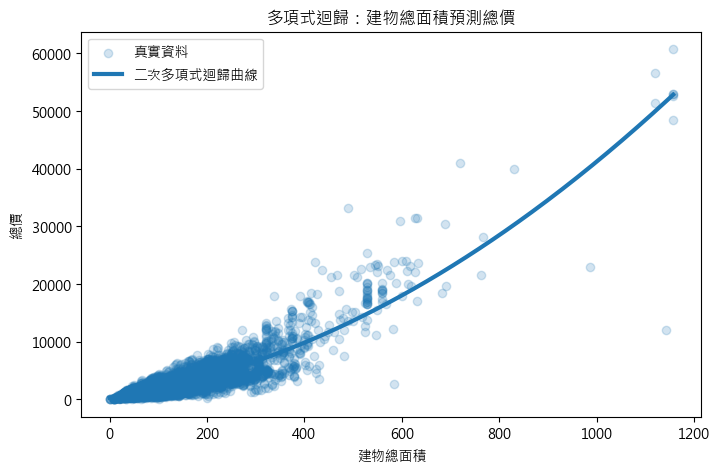

In [22]:
# ============================================================
# 視覺化多項式迴歸曲線
# ============================================================

# 建立從最小建物總面積到最大建物總面積的連續點
area_min = df["建物總面積"].min()
area_max = df["建物總面積"].max()

area_grid = np.linspace(area_min, area_max, 300)
area_grid_df = pd.DataFrame({
    "建物總面積": area_grid
})

# 將連續點轉成多項式特徵
area_grid_poly = poly.transform(area_grid_df)

# 預測曲線
area_grid_pred = poly_model.predict(area_grid_poly)

# 畫圖
plt.scatter(df["建物總面積"], df["總價"], alpha=0.2, label="真實資料")
plt.plot(area_grid, area_grid_pred, linewidth=3, label="二次多項式迴歸曲線")

plt.xlabel("建物總面積")
plt.ylabel("總價")
plt.title("多項式迴歸：建物總面積預測總價")
plt.legend()

plt.show()

### 作業問題 10

請回答：

1. 多項式迴歸線是否比簡單線性迴歸線更彎曲？
2. 多項式次數越高一定越好嗎？為什麼？

## 12. 隨機森林迴歸

隨機森林迴歸是樹模型的一種，屬於集成學習方法。

它會建立多棵決策樹，最後把多棵樹的預測結果平均。

特色：

- 可以學習非線性關係
- 通常不需要標準化
- 可以查看特徵重要性
- 但模型比較不容易像線性迴歸一樣直接解釋係數

In [23]:
# 建立隨機森林迴歸模型
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 訓練模型
rf_model.fit(X_train, y_train)

# 預測
rf_pred = rf_model.predict(X_test)

# 評估 RMSE
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print("隨機森林迴歸 RMSE：", rf_rmse)

隨機森林迴歸 RMSE： 758.9261065054482


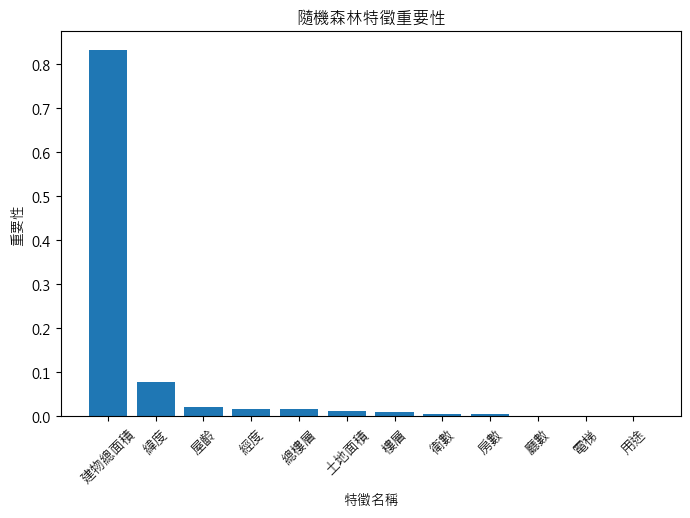

,特徵名稱,重要性
1,建物總面積,0.831648
11,緯度,0.078284
2,屋齡,0.021129
10,經度,0.016530
4,總樓層,0.015793
0,土地面積,0.013249
3,樓層,0.009983
8,衛數,0.005407
6,房數,0.004907
7,廳數,0.001331


In [24]:
# ============================================================
# 視覺化：隨機森林特徵重要性
# ============================================================

importance_df = pd.DataFrame({
    "特徵名稱": feature_columns,
    "重要性": rf_model.feature_importances_
})

# 依照重要性由大到小排序
importance_df = importance_df.sort_values("重要性", ascending=False)

plt.bar(importance_df["特徵名稱"], importance_df["重要性"])

plt.xlabel("特徵名稱")
plt.ylabel("重要性")
plt.title("隨機森林特徵重要性")
plt.xticks(rotation=45)

plt.show()

importance_df

### 作業問題 11

請回答：

1. 隨機森林的 RMSE 是否比多元線性迴歸低？
2. 哪一個特徵的重要性最高？
3. 你認為這個結果合理嗎？為什麼？

## 13. 模型比較

最後把本作業中幾個模型的 RMSE 放在一起比較。

RMSE 越小，表示模型預測誤差越小。

In [25]:
# 建立模型比較表
model_result_df = pd.DataFrame({
    "模型": [
        "多元線性迴歸",
        "Ridge Regression",
        "多項式迴歸",
        "隨機森林迴歸"
    ],
    "RMSE": [
        multiple_rmse,
        ridge_rmse,
        poly_rmse,
        rf_rmse
    ]
})

model_result_df

,模型,RMSE
0,多元線性迴歸,1252.919086
1,Ridge Regression,1252.979948
2,多項式迴歸,1123.068930
3,隨機森林迴歸,758.926107


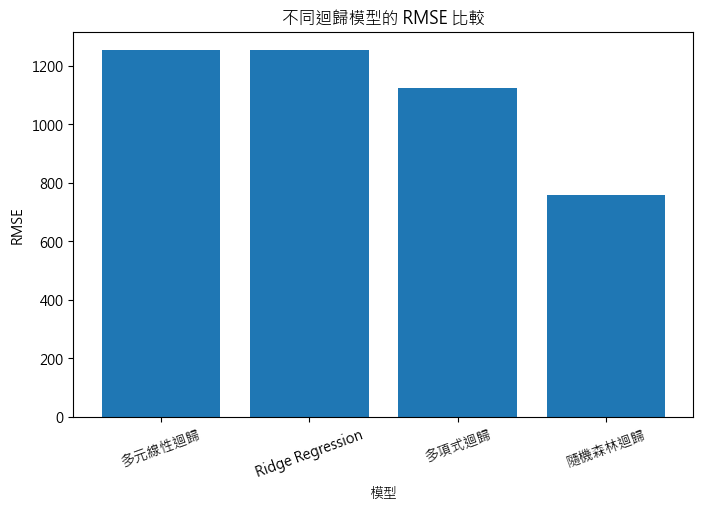

In [26]:
# 視覺化模型比較結果

plt.bar(model_result_df["模型"], model_result_df["RMSE"])

plt.xlabel("模型")
plt.ylabel("RMSE")
plt.title("不同迴歸模型的 RMSE 比較")
plt.xticks(rotation=20)

plt.show()

### 作業問題 12

請根據模型比較表回答：

1. 哪一個模型的 RMSE 最低？
2. 哪一個模型的 RMSE 最高？
3. 如果只看 RMSE，你會選哪個模型？
4. 除了 RMSE，你覺得還應該考慮哪些因素？

## 14. 延伸練習

請選擇其中一題完成：

### 題目 A：加入類別特徵

目前模型沒有使用 `行政區` 與 `車位類別`。

請使用 `pd.get_dummies()` 將類別欄位轉成數值欄位後，再重新訓練模型。

提示：

```python
df_dummies = pd.get_dummies(df, columns=["行政區", "車位類別"], drop_first=True)
```

---

### 題目 B：移除極端值

請觀察 `總價` 的分布，嘗試移除總價特別高的資料，再重新訓練模型。

提示：

```python
df_filtered = df[df["總價"] < 10000]
```

---

### 題目 C：修改隨機森林參數

請修改：

```python
n_estimators=50
n_estimators=200
```

比較不同樹的數量是否會影響 RMSE。

## 作業繳交內容

請繳交：

1. 完成後的 `.ipynb` 檔案
2. 作業問題 1 到 12 的回答
3. 至少一張你認為最重要的視覺化圖表
4. 一段簡短心得：你認為哪一種模型最適合這份資料？為什麼？